In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize


In [2]:
plt.rcParams["figure.dpi"] = 150
plt.rcParams["text.usetex"] = True
plt.rcParams["font.size"] = 12


# matplotlib.rcParams['mathtext.fontset'] = 'stix'
# matplotlib.rcParams['font.family'] = 'Computer Modern'


plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs
%config InlineBackend.figure_format = 'retina'
#plt.rcParams['axes.grid'] = True

In [3]:
theta = np.deg2rad(np.array([10.5, 20.9, 30.5, 40.0, 50.2, 60.1, 69.2, 78.5]))
theta_errors = np.deg2rad(1 * np.ones(8))

y = np.array([4.5, 9.8, 16.6, 18.5, 23.0, 25.8, 29, 32.9])
y_errors = np.array([1, 1.1, 1.2, 1.3, 1.6, 2.0, 2.8, 5.0])


x = np.sin(theta)
x_errors = np.abs(np.cos(theta) * theta_errors)

t_vals = [19.0, 19.3, 19.5, 18.9, 18.8]
t = np.mean(t_vals)
t_err = 0.5

theta_2 = np.arctan(y / (2 * t))



z = np.sin(theta_2)


n = x / np.sin(theta_2)

n_err = np.sqrt(((2*np.sqrt((t/y)**2  + 1/4)) * x_errors)**2 + (y_errors * 2*x*t**2 / (y**3 * np.sqrt((t/y)**2  + 1/4)))**2 + (t_err * 2*x*t / (y**2 * np.sqrt((t/y)**2  + 1/4)))**2)

#chi_squared = np.sum((reflected - line(incident, m, b))**2 / equiv_errors**2)
#reduced_chi_squared = chi_squared / 6

weights = 1 / n_err**2

weighted_mean = np.sum(weights * n) / np.sum(weights)
weighted_std = np.sqrt(1 / np.sum(weights))

print(weighted_mean, weighted_std, weighted_std / np.sqrt(len(n)))

print(n)
print(n_err)



1.4677766009235385 0.03767889571818041 0.013321501334973068
[1.55767391 1.43558063 1.27346054 1.47472722 1.4894574  1.54886966
 1.5460346  1.50160146]
[0.37375966 0.16854012 0.09058805 0.0946838  0.08408972 0.08840706
 0.09864911 0.13305705]


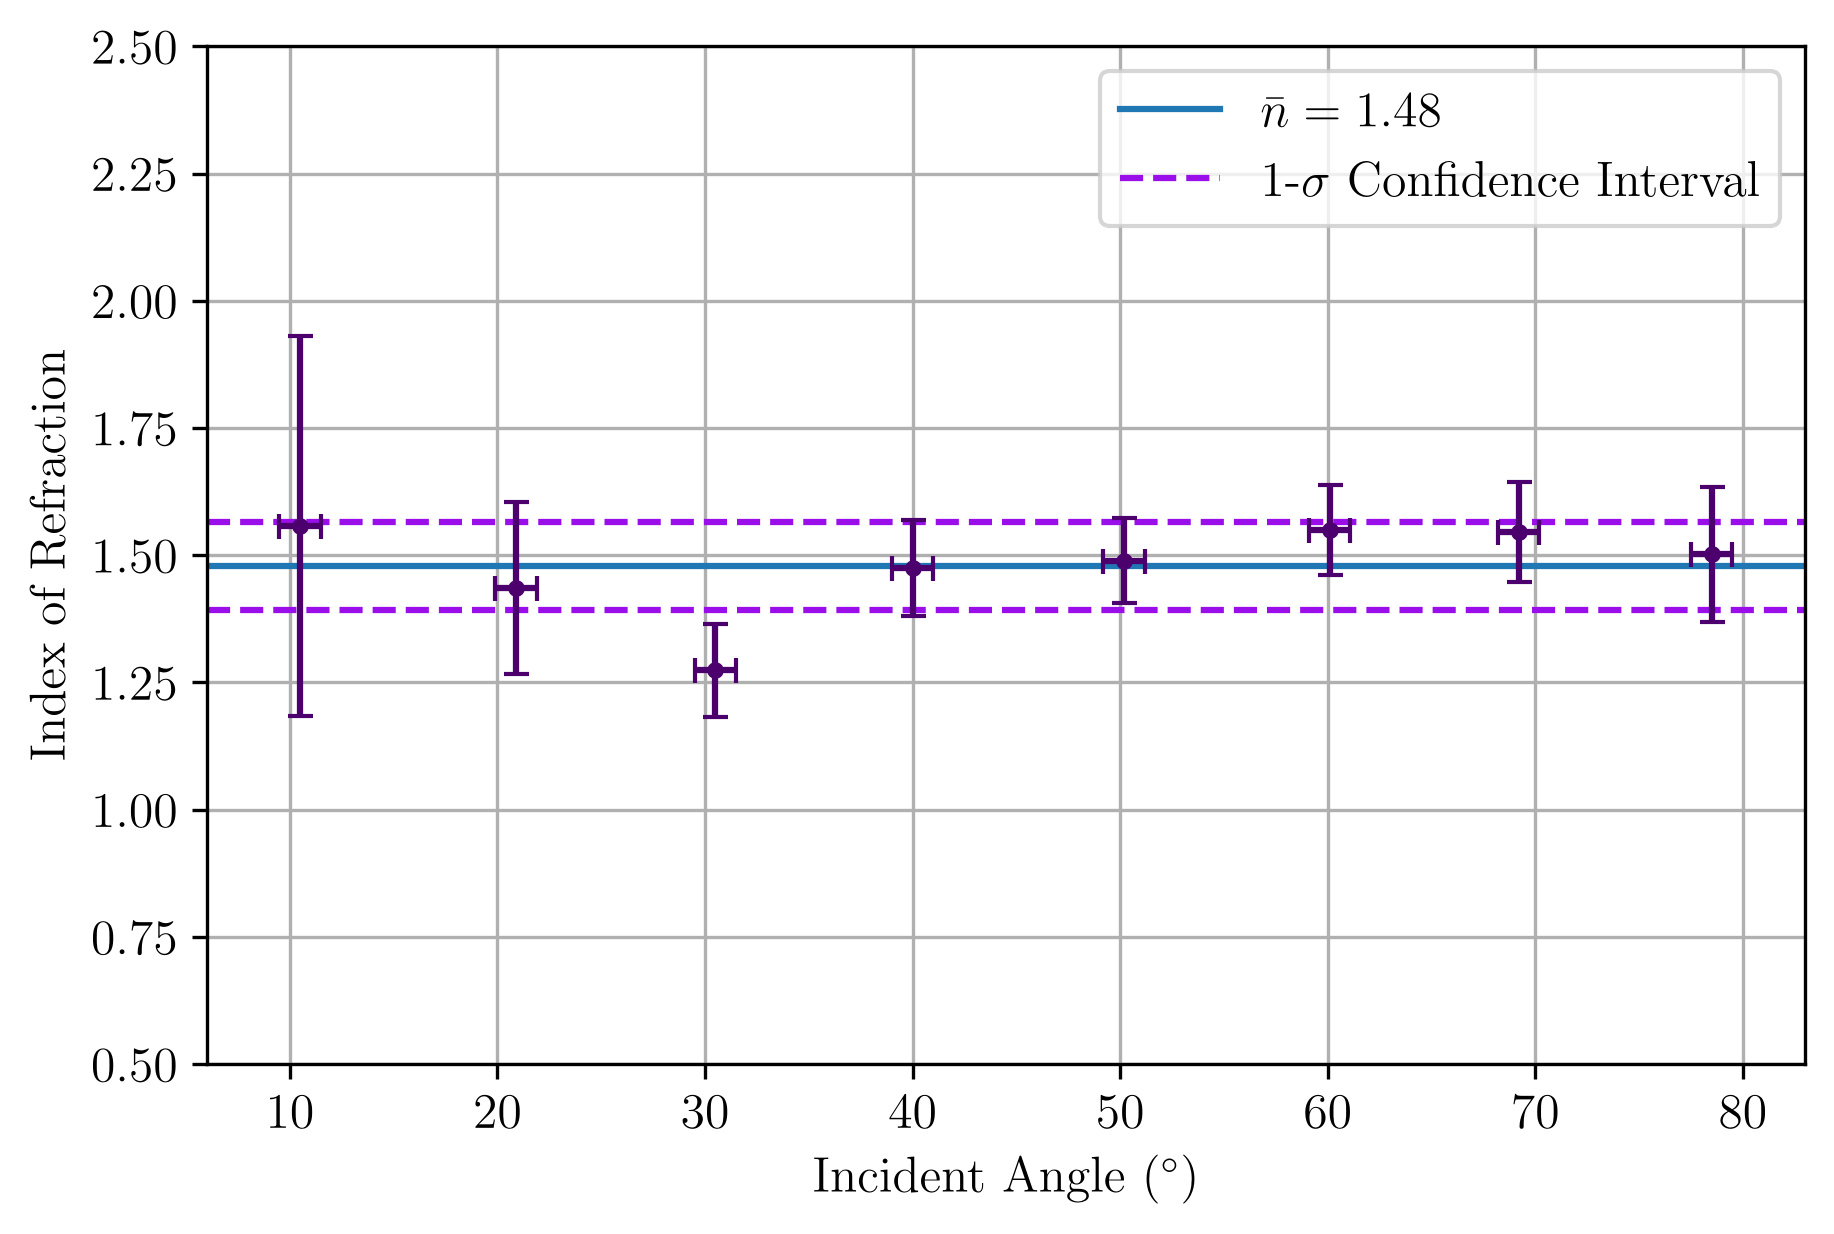

In [4]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")

ax.errorbar(np.rad2deg(theta), n, n_err, np.rad2deg(theta_errors), fmt = 'o', markersize = 3, capsize = 3, color = 'xkcd:royal purple', zorder=10)

ax.axhline(np.mean(n), label=rf"$\bar{{n}} = {np.mean(n):0.2f}$")

ax.axhline(np.mean(n) - np.std(n), linestyle="dashed", color = "xkcd:violet")
ax.axhline(np.mean(n) + np.std(n), linestyle="dashed", color = "xkcd:violet", label=rf"1-$\sigma$ Confidence Interval")


ax.set_ylim(0.5, 2.5)

ax.set_title(r"")
ax.set_xlabel(r"Incident Angle $(^\circ)$")
ax.set_ylabel(r"Index of Refraction")
ax.grid()
ax.legend()

fig.savefig("exp2_plot.png", dpi=400)

